In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split

<div style="display:inline-block; padding:14px 30px; border-radius:40px 12px 40px 12px; background:#fad6c7; color:#6b3f2b; font-family:'Segoe UI',sans-serif; font-size:1.6rem; font-weight:500; box-shadow:0 6px 18px rgba(0,0,0,0.06); border:1px solid rgba(255,255,255,0.4);">
    🌸 Tina Hafezi
</div>

In [2]:
from sklearn.datasets import load_iris

In [3]:
data = load_iris()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", data.target_names)

X shape: (150, 4)
y shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


In [4]:
feature_names = data.feature_names
print(feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


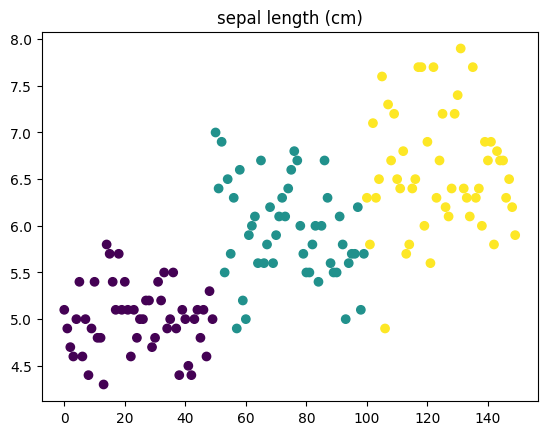

In [5]:
plt.scatter(range(len(X)), X[:, 0], c=y)
plt.title(feature_names[0])
plt.show()

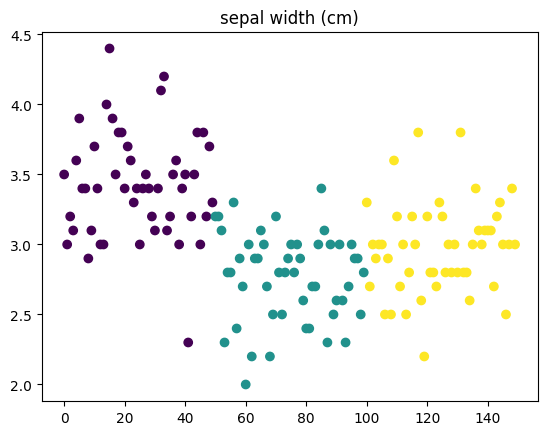

In [6]:
plt.scatter(range(len(X)), X[:, 1], c=y)
plt.title(feature_names[1])
plt.show()

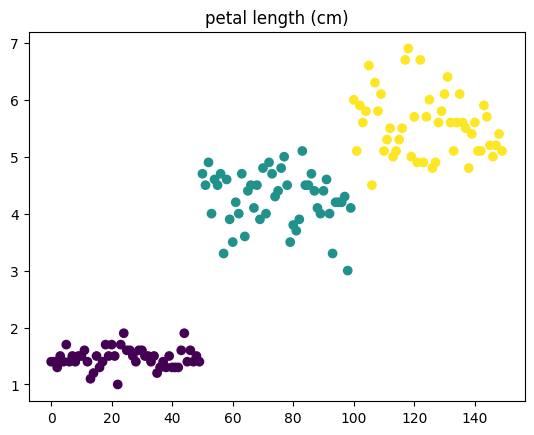

In [7]:
plt.scatter(range(len(X)), X[:, 2], c=y)
plt.title(feature_names[2])
plt.show()

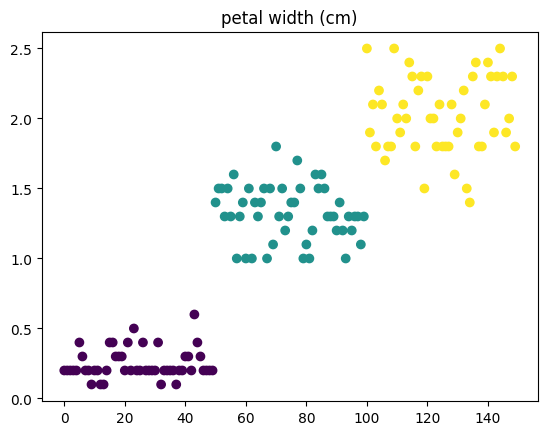

In [8]:
plt.scatter(range(len(X)), X[:, 3], c=y)
plt.title(feature_names[3])
plt.show()

In [29]:
encoder = OneHotEncoder(sparse_output=False)

Y = encoder.fit_transform(y.reshape(-1, 1))

print(Y[:10])

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [30]:
normz = StandardScaler()
X = normz.fit_transform(X)

print(X.mean(axis=0))
print(X.std(axis=0))

[ 1.79578574e-16  1.09171931e-17 -5.58812256e-16  5.27726011e-16]
[1. 1. 1. 1.]


<div style="display:inline-block; padding:14px 30px; border-radius:40px 12px 40px 12px; background:#b7d7f0; color:#1e3c5c; font-family:'Segoe UI',sans-serif; font-size:1.6rem; font-weight:500; box-shadow:0 6px 18px rgba(0,0,0,0.06); border:1px solid rgba(255,255,255,0.4);">
    ⭐ Fatemeh Ebrahimi
</div>

In [42]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,stratify=Y,shuffle=True)

In [43]:
y_train

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0

In [44]:
def sigmoid(x):
    return 1 / (1 + np.e ** (-x))

In [45]:
def logistic_regression(x,w):
    return sigmoid(x @ w.T)

In [46]:
def binary_cross_entropy(y,y_hat):
    return np.mean(-( y * np.log2(y_hat) + (1 - y) * np.log2(1 - y_hat)))

In [ ]:
def gradient(x, y, y_hat):
    return (x.T @ (y_hat - y)) / len(y)

In [ ]:
def update(w,grad,eta=0.1):
    return w - eta * grad

Main Training loop

In [ ]:
w = np.random.random((3,4))

In [51]:
epoches = 100

for epoch in range(epoches):

    model_setosa_predict = logistic_regression(X_train,w[0])
    model_versicolor_predict = logistic_regression(X_train,w[1])
    model_virginica_predict= logistic_regression(X_train,w[2])

    setosa_loss = binary_cross_entropy(y_train[:,0],model_setosa_predict)
    versicolor_loss = binary_cross_entropy(y_train[:,1],model_versicolor_predict)
    virginica_loss = binary_cross_entropy(y_train[:,2],model_virginica_predict)

    w[0] = update(w[0],gradient(X_train,y_train[:,0],model_setosa_predict))
    w[1] = update(w[1],gradient(X_train,y_train[:,1],model_versicolor_predict))
    w[2] = update(w[2],gradient(X_train,y_train[:,2],model_virginica_predict))

    print(f'losses : {np.mean(setosa_loss)}\t {np.mean(versicolor_loss)}\t {np.mean(virginica_loss)}')

losses : 2.08770426494002	 1.3960404845791325	 0.617527232514116
losses : 1.8891550856576378	 1.3674806139131352	 0.613808075553935
losses : 1.7075369291102607	 1.3400685471558635	 0.6103712942945874
losses : 1.5434438926840068	 1.313809547750597	 0.6071898602481558
losses : 1.3968977956400626	 1.2887042950449086	 0.604239764310757
losses : 1.267353895948131	 1.2647487671464968	 0.6014996336146389
losses : 1.153785622586471	 1.2419342039093093	 0.5989504022647306
losses : 1.0548229034298704	 1.2202471540348754	 0.5965750277468154
losses : 0.9689078748362081	 1.1996696071726325	 0.5943582461232704
losses : 0.8944355723159291	 1.180179208632567	 0.5922863602376957
losses : 0.8298603571726716	 1.16174955109505	 0.5903470560697568
losses : 0.7737631864747674	 1.144350534730549	 0.5885292431479142
losses : 0.7248847681745488	 1.127948784621517	 0.5868229155667902
losses : 0.6821338651784769	 1.1125081124678147	 0.5852190306895693
losses : 0.6445800596619762	 1.0979900083604561	 0.5837094030

In [54]:
np.argmax((model_setosa_predict,model_versicolor_predict,model_virginica_predict),axis=0)

array([1, 2, 1, 2, 0, 0, 1, 2, 1, 0, 2, 2, 2, 0, 2, 2, 1, 0, 1, 2, 1, 0,
       0, 2, 2, 1, 1, 2, 0, 2, 0, 2, 0, 0, 0, 1, 2, 0, 2, 2, 2, 1, 0, 2,
       2, 2, 1, 2, 1, 0, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0, 0, 0,
       1, 0, 2, 1, 2, 2, 2, 0, 2, 0, 2, 0, 0, 0, 2, 2, 0, 0, 0, 1, 1, 0,
       1, 2, 0, 2, 2, 2, 2, 0, 1, 2, 2, 0, 1, 2, 1, 0, 0, 1, 1, 2, 1, 0,
       2, 0, 2, 2, 1, 0, 1, 2, 2, 0])

In [56]:
np.argmax((model_setosa_predict,model_versicolor_predict,model_virginica_predict),axis=0).shape

(120,)

In [58]:
np.argmax(y_train,axis=1).shape

(120,)

In [62]:
np.argmax((model_setosa_predict,model_versicolor_predict,model_virginica_predict),axis=0) == np.argmax(y_train,axis=1)

array([ True, False,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True, False,  True, False,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False,  True,  True,  True,  True,  True,  True, False,  True,
        True, False, False, False,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True, False, False,  True,  True, False,
        True,  True,  True])

Final Train Accuracy

In [63]:
np.sum(np.argmax((model_setosa_predict,model_versicolor_predict,model_virginica_predict),axis=0) == np.argmax(y_train,axis=1))

np.int64(100)

In [68]:
np.sum(np.argmax((model_setosa_predict,model_versicolor_predict,model_virginica_predict),axis=0) == np.argmax(y_train,axis=1)) / len(y_train[:,0])

np.float64(0.8333333333333334)

<div style="display:inline-block; padding:14px 30px; border-radius:40px 12px 40px 12px; background:#c7e9d0; color:#1e4d3a; font-family:'Segoe UI',sans-serif; font-size:1.6rem; font-weight:500; box-shadow:0 6px 18px rgba(0,0,0,0.06); border:1px solid rgba(255,255,255,0.4);">
    🌿 Fatemeh Habib Zadeh
</div>